# Notebook 03 — Statistical Analysis

This notebook conducts the statistical analysis of the ablation study results
produced in Notebook 02. All F1 scores are loaded from `ablation_results.json`
in the consolidated results dataset.

The analysis addresses three questions:

1. Does KG augmentation produce a statistically significant improvement over
   the no-KG baseline under either fusion architecture?
2. Does fusion architecture (late vs additive) produce a statistically
   significant difference in test F1 within each KG source condition?
3. Does KG source (Phase A vs Phase B) produce a statistically significant
   difference in test F1 within each fusion architecture?

Each comparison uses a two-sided Wilcoxon signed-rank test (n=7 seeds).
Effect sizes are reported as rank-biserial correlation coefficients. Given
the sample size, the analysis is underpowered for small effects; findings
are interpreted accordingly.

Results are interpreted in the context of the coverage ceiling established
in Notebook 00: 73–81% of test entities receive no KG signal under any
condition. This is treated as the primary explanatory mechanism for any
null results observed.

In [2]:
import json
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

In [3]:
results_path = '/kaggle/input/datasets/michaelmarkey64/irish-ner-ablation-results/ablation_results.json'

with open(results_path) as f:
    results_all = json.load(f)

# Build a dict of condition -> array of test F1 scores across seeds
# Seed order is preserved to allow paired comparisons
test_f1s = {}
val_f1s  = {}

for condition, seed_results in results_all.items():
    sorted_seeds = sorted(seed_results.keys(), key=lambda x: int(x))
    test_f1s[condition] = np.array([seed_results[s]['test_f1'] for s in sorted_seeds])
    val_f1s[condition]  = np.array([seed_results[s]['val_f1']  for s in sorted_seeds])

# Confirm all conditions present and seed counts consistent
for condition, arr in test_f1s.items():
    print(f'{condition}: {len(arr)} seeds, mean test F1: {arr.mean():.4f}, std: {arr.std():.4f}')

no_kg: 7 seeds, mean test F1: 0.8264, std: 0.0064
A_late: 7 seeds, mean test F1: 0.8265, std: 0.0075
A_additive: 7 seeds, mean test F1: 0.8205, std: 0.0076
B_late: 7 seeds, mean test F1: 0.8254, std: 0.0071
B_additive: 7 seeds, mean test F1: 0.8224, std: 0.0064


## Statistical Testing Approach

Pairwise comparisons use the two-sided Wilcoxon signed-rank test. The
signed-rank test is preferred over a paired t-test given the small sample
size (n=7 seeds) and the absence of any basis for assuming normality in the
F1 score distributions.

With n=7, the minimum achievable p-value under the Wilcoxon signed-rank test
is 0.0156 (all differences in the same direction). Any result above this
threshold is non-significant by construction regardless of the observed
difference in means. This is an acknowledged limitation of the design and is
a direct consequence of the computational cost of running more seeds.

Effect size is reported as rank-biserial correlation (r), where 0.1, 0.3,
and 0.5 are conventionally interpreted as small, medium, and large effects.

In [5]:
def wilcoxon_comparison(label_a, label_b, test_f1s):
    # Paired Wilcoxon signed-rank test between two conditions
    # Returns a summary dict with means, difference, statistic, p-value,
    # and rank-biserial effect size
    a = test_f1s[label_a]
    b = test_f1s[label_b]
    diff = a - b

    # Wilcoxon requires at least one non-zero difference
    if np.all(diff == 0):
        return {
            'comparison':  f'{label_a} vs {label_b}',
            'mean_a':      a.mean(),
            'mean_b':      b.mean(),
            'mean_diff':   0.0,
            'statistic':   np.nan,
            'p_value':     np.nan,
            'effect_r':    np.nan,
            'significant': False,
            'note':        'all differences zero'
        }

    stat, p = wilcoxon(a, b, alternative='two-sided')

    # Rank-biserial correlation as effect size
    n = len(a)
    r = 1 - (2 * stat) / (n * (n + 1) / 2)

    return {
        'comparison':  f'{label_a} vs {label_b}',
        'mean_a':      a.mean(),
        'mean_b':      b.mean(),
        'mean_diff':   (a - b).mean(),
        'statistic':   stat,
        'p_value':     p,
        'effect_r':    r,
        'significant': p < 0.05
    }

In [6]:
comparisons = [
    # Question 1: KG vs no-KG baseline
    ('A_late',     'no_kg'),
    ('A_additive', 'no_kg'),
    ('B_late',     'no_kg'),
    ('B_additive', 'no_kg'),
    # Question 2: fusion architecture effect within each KG source
    ('A_late', 'A_additive'),
    ('B_late', 'B_additive'),
    # Question 3: KG source effect within each fusion type
    ('A_late',      'B_late'),
    ('A_additive',  'B_additive'),
]

rows = [wilcoxon_comparison(a, b, test_f1s) for a, b in comparisons]
results_df = pd.DataFrame(rows)

print(results_df[[
    'comparison', 'mean_a', 'mean_b', 'mean_diff', 'p_value', 'effect_r', 'significant'
]].to_string(index=False, float_format='{:.4f}'.format))

              comparison  mean_a  mean_b  mean_diff  p_value  effect_r  significant
         A_late vs no_kg  0.8265  0.8264     0.0001   0.6875    0.2143        False
     A_additive vs no_kg  0.8205  0.8264    -0.0059   0.1094    0.7143        False
         B_late vs no_kg  0.8254  0.8264    -0.0010   0.1562    0.6429        False
     B_additive vs no_kg  0.8224  0.8264    -0.0040   0.4688    0.3571        False
    A_late vs A_additive  0.8265  0.8205     0.0060   0.2188    0.5714        False
    B_late vs B_additive  0.8254  0.8224     0.0030   0.5781    0.2857        False
        A_late vs B_late  0.8265  0.8254     0.0011   0.2969    0.5000        False
A_additive vs B_additive  0.8205  0.8224    -0.0019   0.1094    0.7143        False


## Results

All eight pairwise comparisons are non-significant at α = 0.05. No KG
condition differs from the no-KG baseline, no fusion architecture effect
is detectable within either KG source, and no KG source effect is detectable
within either fusion architecture.

Several features of the results warrant comment.

**KG vs baseline:** A_late is the only KG condition that marginally exceeds
the no-KG baseline (mean diff +0.0001), and this is negligible by any
measure. The remaining three KG conditions perform below baseline, with
A_additive showing the largest deficit (mean diff -0.0059, p=0.1094,
r=0.71). The effect size for A_additive vs no_kg is notably large despite
non-significance — a pattern consistent with a real but noisy effect that
the sample size is insufficient to resolve. This should be interpreted
cautiously rather than dismissed.

**Fusion architecture:** Late fusion consistently outperforms additive fusion
(A_late > A_additive by 0.0060; B_late > B_additive by 0.0030), but neither
comparison reaches significance. The pattern is directionally consistent
across both KG sources, which provides weak corroborating evidence for a
fusion architecture effect that a larger seed set might resolve.

**KG source:** Phase A and Phase B are statistically indistinguishable under
both fusion architectures. The mean differences are negligible (0.0011 and
-0.0019 respectively).

The primary explanatory mechanism for these null results is the coverage
ceiling established in Notebook 00: 73–81% of test entities receive no KG
signal under any condition. With the majority of tokens receiving a zero
vector, aggregate F1 is dominated by the BERT-CRF component and the KG
augmentation has insufficient purchase to produce a detectable effect.

In [7]:
# Compare all conditions against the Adkins et al. 2025 reported F1 of 0.7652
# Note: direct statistical comparison is not possible as per-seed scores from
# Adkins et al. are not available; this is a descriptive comparison only

adkins_f1 = 0.7652

rows = []
for condition, scores in test_f1s.items():
    margin = scores.mean() - adkins_f1
    rows.append({
        'condition':   condition,
        'mean_test_f1': scores.mean(),
        'vs_adkins':   margin,
    })

adkins_df = pd.DataFrame(rows).sort_values('mean_test_f1', ascending=False)

print('Descriptive comparison against Adkins et al. 2025 (F1 = 0.7652)')
print('Note: no statistical test possible — per-seed Adkins scores unavailable')
print()
print(adkins_df.to_string(index=False, float_format='{:.4f}'.format))

Descriptive comparison against Adkins et al. 2025 (F1 = 0.7652)
Note: no statistical test possible — per-seed Adkins scores unavailable

 condition  mean_test_f1  vs_adkins
    A_late        0.8265     0.0613
     no_kg        0.8264     0.0612
    B_late        0.8254     0.0602
B_additive        0.8224     0.0572
A_additive        0.8205     0.0553


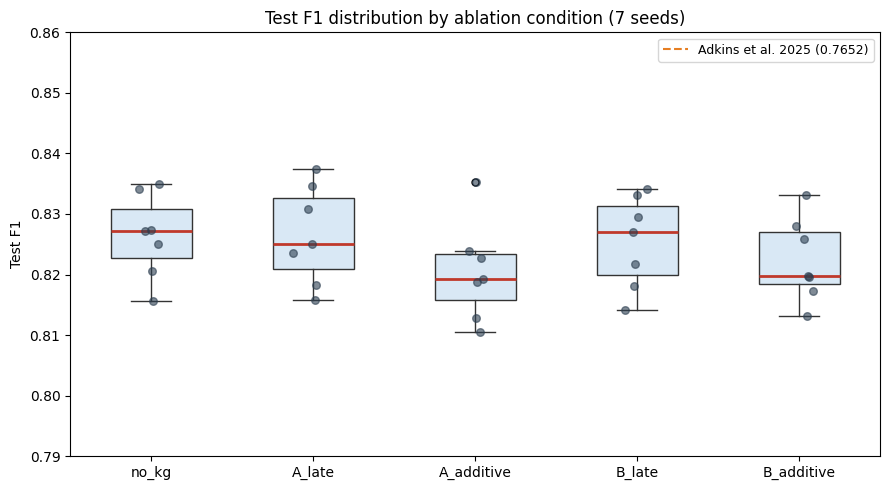

Figure saved to ablation_f1_distributions.png


In [11]:
import matplotlib.pyplot as plt

WORKING = '/kaggle/working'
adkins_f1 = 0.7652

conditions = list(test_f1s.keys())
data       = [test_f1s[c] for c in conditions]

fig, ax = plt.subplots(figsize=(9, 5))

ax.boxplot(data, tick_labels=conditions, patch_artist=True,
           boxprops=dict(facecolor='#d9e8f5', color='#333'),
           medianprops=dict(color='#c0392b', linewidth=2),
           whiskerprops=dict(color='#333'),
           capprops=dict(color='#333'),
           flierprops=dict(marker='o', color='#999', markersize=5))

for i, d in enumerate(data):
    x = np.random.normal(i + 1, 0.04, size=len(d))
    ax.scatter(x, d, alpha=0.6, s=30, color='#2c3e50', zorder=3)

ax.axhline(y=adkins_f1, color='#e67e22', linestyle='--',
           linewidth=1.5, label=f'Adkins et al. 2025 ({adkins_f1})')

ax.set_ylabel('Test F1')
ax.set_title('Test F1 distribution by ablation condition (7 seeds)')
ax.legend(fontsize=9)
ax.set_ylim(0.79, 0.86)
plt.tight_layout()
plt.savefig(f'{WORKING}/ablation_f1_distributions.png', dpi=150)
plt.show()
print('Figure saved to ablation_f1_distributions.png')

## Coverage Ceiling as Explanatory Mechanism

The null results across all eight comparisons are consistent with the
coverage ceiling established in Notebook 00. The relevant figures are
reproduced here for interpretive continuity.

Under Phase A augmentation, 73–81% of test entities receive a zero vector.
Under Phase B augmentation the figure is comparable despite the different
construction methodology, reflecting the structural mismatch between the
parliamentary co-occurrence corpus and the broader Adkins test set.

The implication is that aggregate F1 is dominated by the BERT-CRF component
in the overwhelming majority of token-level decisions. The KG augmentation
is only active on a small fraction of the input, and the zero-vector fallback
is not a neutral operation under additive fusion — a zero vector projected
through a learned linear layer produces a non-zero additive perturbation,
which may partly explain the consistent underperformance of additive
conditions relative to late fusion, where the zero vector is simply
concatenated and the classifier can in principle learn to ignore it.

Expanding coverage is the necessary condition for KG augmentation to produce
a detectable effect at the aggregate level. The parliamentary corpus
experiment (Phase B) demonstrated that domain-matched expansion does not
resolve the coverage problem when the target test distribution includes
entity types underrepresented in the augmentation source. A purpose-built
Irish NER-focused knowledge graph, or a retrieval-based augmentation strategy
operating at inference time, would be required to materially alter the
coverage constraint.

In [12]:
# Final summary table for dissertation reporting
summary_rows = []
for condition, scores in test_f1s.items():
    summary_rows.append({
        'Condition':    condition,
        'Mean F1':      scores.mean(),
        'Std':          scores.std(),
        'Min':          scores.min(),
        'Max':          scores.max(),
        'vs Adkins':    scores.mean() - adkins_f1,
        'vs no_kg':     scores.mean() - test_f1s['no_kg'].mean()
    })

summary_df = (pd.DataFrame(summary_rows)
              .sort_values('Mean F1', ascending=False)
              .reset_index(drop=True))

print(summary_df.to_string(index=False, float_format='{:.4f}'.format))

# Save to working directory for dissertation appendix
summary_df.to_csv(f'{WORKING}/ablation_summary_table.csv', index=False)
print(f'\nSummary table saved to ablation_summary_table.csv')

 Condition  Mean F1    Std    Min    Max  vs Adkins  vs no_kg
    A_late   0.8265 0.0075 0.8158 0.8374     0.0613    0.0001
     no_kg   0.8264 0.0064 0.8156 0.8349     0.0612    0.0000
    B_late   0.8254 0.0071 0.8141 0.8342     0.0602   -0.0010
B_additive   0.8224 0.0064 0.8132 0.8331     0.0572   -0.0040
A_additive   0.8205 0.0076 0.8106 0.8353     0.0553   -0.0059

Summary table saved to ablation_summary_table.csv


## Conclusions

The ablation study yields three principal findings.

**Finding 1: KG augmentation produces no statistically significant
improvement over the no-KG baseline under any condition.** All four KG
conditions fail to improve on the zero-vector baseline at α=0.05. The
coverage ceiling — 73–81% of test entities receiving no KG signal — is
the primary explanatory mechanism. The KG augmentation has insufficient
purchase on the test distribution to produce a detectable aggregate effect.

**Finding 2: Late fusion is consistently but not significantly superior to
additive fusion.** The directional pattern holds across both KG sources
(A_late > A_additive by 0.0060; B_late > B_additive by 0.0030). The
underperformance of additive fusion under high miss-rate conditions is
consistent with the hypothesis that zero-vector projection introduces a
learned perturbation that late fusion avoids by simple concatenation.
This finding warrants investigation under higher-coverage conditions.

**Finding 3: KG source has no detectable effect on performance.** Phase A
(Wikidata-derived) and Phase B (parliamentary co-occurrence) are
statistically indistinguishable, despite different construction
methodologies and lookup pathways. Domain-matched expansion does not
resolve the coverage constraint when the target distribution includes
entity types underrepresented in the augmentation source.

**Overall baseline performance** substantially exceeds the Adkins et al.
2025 reference F1 of 0.7652 by approximately 0.06 across all conditions.
The source of this gap — whether architectural or procedural — is not
resolved within this study and warrants examination before cross-study
comparisons are drawn.

The study establishes coverage expansion, rather than architectural
refinement, as the binding constraint for KG-augmented Irish NER. A
retrieval-based augmentation strategy operating at inference time is
identified as a candidate direction for future work.